In [ ]:
!pip install ultralytics opencv-python-headless

In [ ]:
from ultralytics import YOLO

model = YOLO("yolov8n.pt")  # fast model

In [ ]:
import cv2
from ultralytics import YOLO

model = YOLO("yolov8n.pt")
cap = cv2.VideoCapture(0)

while True:
    ret, frame = cap.read()
    if not ret:
        break

    results = model(frame)
    annotated = results[0].plot()

    cv2.imshow("YOLO Detection", annotated)

    if cv2.waitKey(1) & 0xFF == ord('q'):
        break

cap.release()
cv2.destroyAllWindows()

<IPython.core.display.Javascript object>


image 1/1 /content/photo.jpg: 480x640 2 persons, 1 cup, 1 clock, 232.4ms
Speed: 2.3ms preprocess, 232.4ms inference, 1.4ms postprocess per image at shape (1, 3, 480, 640)


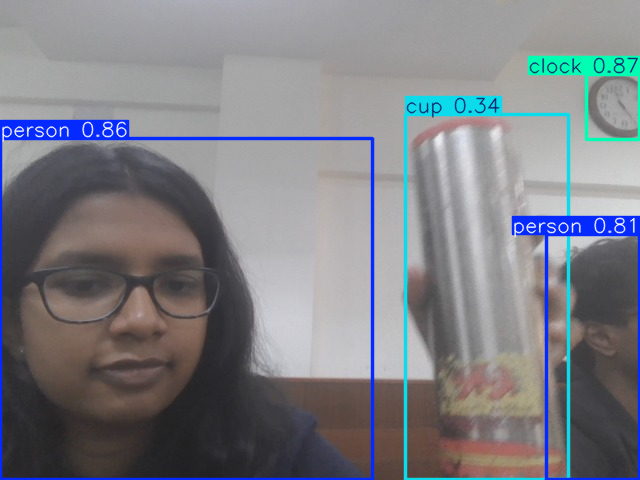

<IPython.core.display.Javascript object>


image 1/1 /content/photo.jpg: 480x640 3 persons, 1 clock, 288.4ms
Speed: 4.7ms preprocess, 288.4ms inference, 1.5ms postprocess per image at shape (1, 3, 480, 640)


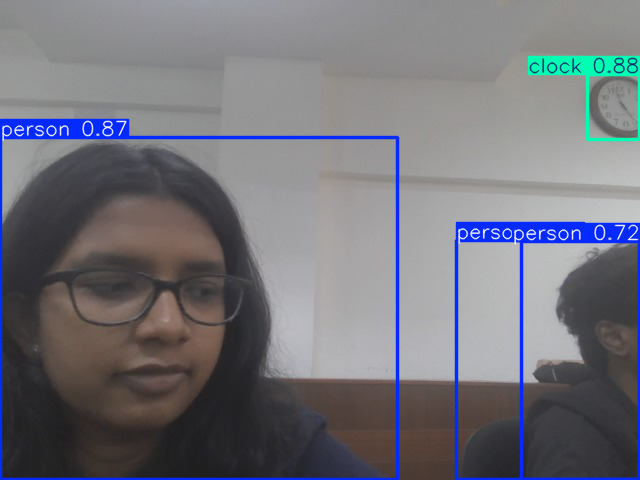

In [ ]:
import cv2
import numpy as np
from google.colab.patches import cv2_imshow
from IPython.display import display, Javascript
from base64 import b64decode
from google.colab.output import eval_js

# JS to capture webcam image
def take_photo():
    js = Javascript('''
        async function takePhoto() {
            const div = document.createElement('div');
            const video = document.createElement('video');
            video.style.display = 'block';
            const stream = await navigator.mediaDevices.getUserMedia({video: true});

            document.body.appendChild(div);
            div.appendChild(video);
            video.srcObject = stream;
            await video.play();

            await new Promise(resolve => setTimeout(resolve, 1000));

            const canvas = document.createElement('canvas');
            canvas.width = video.videoWidth;
            canvas.height = video.videoHeight;
            canvas.getContext('2d').drawImage(video, 0, 0);

            stream.getTracks().forEach(track => track.stop());
            div.remove();

            return canvas.toDataURL('image/jpeg');
        }
    ''')
    display(js)
    data = eval_js('takePhoto()')
    binary = b64decode(data.split(',')[1])
    with open('photo.jpg', 'wb') as f:
        f.write(binary)

# Loop for "real-time"
for i in range(2):  # captures 10 frames
    take_photo()

    results = model("photo.jpg")

    annotated = results[0].plot()
    cv2_imshow(annotated)